In [1]:
import sys
import os

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import matplotlib.pyplot as plt
import numpy             as np
import pandas            as pd

from tqdm import tqdm

plt.style.use('default');
pltext.style()

In [20]:
pure_signal_1771       = np.load("data_files/nobkgrun_pure_signal_1771.npz")     ["arr_0"]
no_candidates_sig_1771 = np.load("data_files/nobkgrun_sig_noCandidates_1771.npz")["arr_0"]
mc_signal_1771         = np.load("data_files/nobkgrun_mc_signal_1771.npz")       ["arr_0"]
no_candidates_mc_1771  = np.load("data_files/nobkgrun_mc_noCandidates_1771.npz") ["arr_0"]

pure_signal_1767       = np.load("data_files/nobkgrun_pure_signal_1767.npz")     ["arr_0"]
no_candidates_sig_1767 = np.load("data_files/nobkgrun_sig_noCandidates_1767.npz")["arr_0"]
mc_signal_1767         = np.load("data_files/nobkgrun_mc_signal_1767.npz")       ["arr_0"]
no_candidates_mc_1767  = np.load("data_files/nobkgrun_mc_noCandidates_1767.npz") ["arr_0"]

pure_signal_1769       = np.load("data_files/nobkgrun_pure_signal_1769.npz")     ["arr_0"]
no_candidates_sig_1769 = np.load("data_files/nobkgrun_sig_noCandidates_1769.npz")["arr_0"]
mc_signal_1769         = np.load("data_files/nobkgrun_mc_signal_1769.npz")       ["arr_0"]
no_candidates_mc_1769  = np.load("data_files/nobkgrun_mc_noCandidates_1769.npz") ["arr_0"]

In [21]:
def relativeQE_error(signal, mc, sig_candidates, mc_candidates):
    # --- Hits por PMT normalizados ---
    N_data = signal          # conteos por PMT
    N_mc   = mc            # conteos por PMT

    data_hits_per_pmt = N_data / sig_candidates
    mc_hits_per_pmt   = N_mc   / mc_candidates

    # --- Errores Poissonianos por bin ---
    error_data = np.zeros(2014)
    error_mc   = np.zeros(2014)

    mask_data = N_data > 0
    mask_mc   = N_mc   > 0

    error_data[mask_data] = np.sqrt(N_data[mask_data]) / sig_candidates
    error_mc[mask_mc]     = np.sqrt(N_mc[mask_mc])   / mc_candidates

    # --- Ratio Data / MC y su error ---
    relative_qe       = np.zeros(2014)
    error_relative_qe = np.zeros(2014)

    mask = (mc_hits_per_pmt > 0) & (data_hits_per_pmt > 0)

    relative_qe[mask] = data_hits_per_pmt[mask] / mc_hits_per_pmt[mask]

    error_relative_qe[mask] = np.sqrt(
        (error_data[mask] / mc_hits_per_pmt[mask])**2
        +
        (data_hits_per_pmt[mask] * error_mc[mask] / mc_hits_per_pmt[mask]**2)**2
    )

    return relative_qe, error_relative_qe

In [22]:
relative_qe_1771, error_relative_qe_1771 = relativeQE_error(pure_signal_1771, mc_signal_1771, no_candidates_sig_1771, no_candidates_mc_1771)
relative_qe_1767, error_relative_qe_1767 = relativeQE_error(pure_signal_1767, mc_signal_1767, no_candidates_sig_1767, no_candidates_mc_1767)
relative_qe_1769, error_relative_qe_1769 = relativeQE_error(pure_signal_1769, mc_signal_1769, no_candidates_sig_1769, no_candidates_mc_1769)

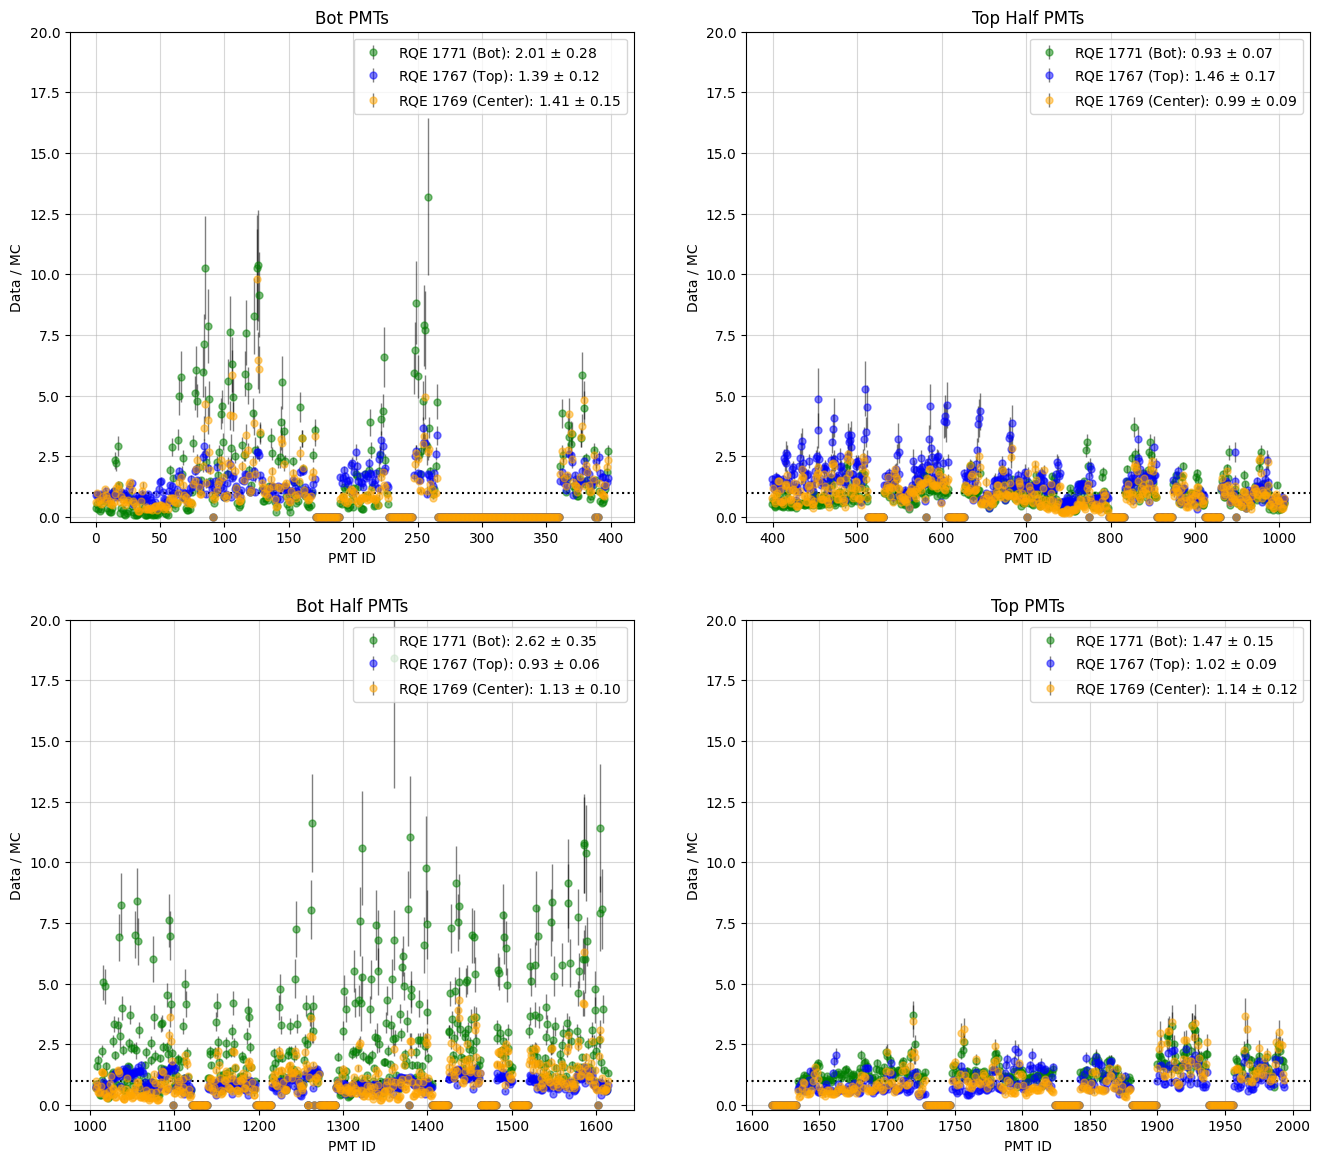

In [24]:
subplot = pltext.canvas(4, 2, 7, 8)

subplot(1)
plt.errorbar(
    range(21*19),
    relative_qe_1771[:21*19],
    yerr=error_relative_qe_1771[:21*19],
    fmt="o",
    markersize=5,
    markerfacecolor="green",
    markeredgecolor="green",
    alpha=0.5,
    ecolor="black",        # color de las barras de error
    elinewidth=1,
    capsize=0,
    label=rf"RQE 1771 (Bot): {np.mean([i for i in relative_qe_1771[:21*19] if i!=0.00]):.2f} $\pm$ {np.mean([i for i in error_relative_qe_1771[:21*19] if i!=0.00]):.2f}"
);
plt.errorbar(
    range(21*19),
    relative_qe_1767[:21*19],
    yerr=error_relative_qe_1767[:21*19],
    fmt="o",
    markersize=5,
    markerfacecolor="blue",
    markeredgecolor="blue",
    alpha=0.5,
    ecolor="black",        # color de las barras de error
    elinewidth=1,
    capsize=0,
    label=f"RQE 1767 (Top): {np.mean([i for i in relative_qe_1767[:21*19] if i!=0.00]):.2f} $\pm$ {np.mean([i for i in error_relative_qe_1767[:21*19] if i!=0.00]):.2f}"
);
plt.errorbar(
    range(21*19),
    relative_qe_1769[:21*19],
    yerr=error_relative_qe_1769[:21*19],
    fmt="o",
    markersize=5,
    markerfacecolor="orange",
    markeredgecolor="orange",
    alpha=0.5,
    ecolor="black",        # color de las barras de error
    elinewidth=1,
    capsize=0,
    label=f"RQE 1769 (Center): {np.mean([i for i in relative_qe_1769[:21*19] if i!=0.00]):.2f} $\pm$ {np.mean([i for i in error_relative_qe_1769[:21*19] if i!=0.00]):.2f}"
);
plt.title("Bot PMTs")
plt.axhline(1.0, linestyle=":", color="k")
plt.ylabel("Data / MC")
plt.xlabel("PMT ID")
plt.grid(alpha=0.5)
plt.ylim(-0.2, 20);
plt.legend(loc="upper right");

subplot(2)
plt.errorbar(
    range(21*19, 53*19),
    relative_qe_1771[21*19:53*19],
    yerr=error_relative_qe_1771[21*19:53*19],
    fmt="o",
    markersize=5,
    markerfacecolor="green",
    markeredgecolor="green",
    alpha=0.5,
    ecolor="black",        # color de las barras de error
    elinewidth=1,
    capsize=0,
    label=f"RQE 1771 (Bot): {np.mean([i for i in relative_qe_1771[21*19:53*19] if i!=0.00]):.2f} $\pm$ {np.mean([i for i in error_relative_qe_1771[21*19:53*19] if i!=0.00]):.2f}"
);
plt.errorbar(
    range(21*19, 53*19),
    relative_qe_1767[21*19:53*19],
    yerr=error_relative_qe_1767[21*19:53*19],
    fmt="o",
    markersize=5,
    markerfacecolor="blue",
    markeredgecolor="blue",
    alpha=0.5,
    ecolor="black",        # color de las barras de error
    elinewidth=1,
    capsize=0,
    label=f"RQE 1767 (Top): {np.mean([i for i in relative_qe_1767[21*19:53*19] if i!=0.00]):.2f} $\pm$ {np.mean([i for i in error_relative_qe_1767[21*19:53*19] if i!=0.00]):.2f}"
);
plt.errorbar(
    range(21*19, 53*19),
    relative_qe_1769[21*19:53*19],
    yerr=error_relative_qe_1769[21*19:53*19],
    fmt="o",
    markersize=5,
    markerfacecolor="orange",
    markeredgecolor="orange",
    alpha=0.5,
    ecolor="black",        # color de las barras de error
    elinewidth=1,
    capsize=0,
    label=f"RQE 1769 (Center): {np.mean([i for i in relative_qe_1769[21*19:53*19] if i!=0.00]):.2f} $\pm$ {np.mean([i for i in error_relative_qe_1769[21*19:53*19] if i!=0.00]):.2f}"
);
plt.title("Top Half PMTs")
plt.axhline(1.0, linestyle=":", color="k")
plt.ylabel("Data / MC")
plt.xlabel("PMT ID")
plt.grid(alpha=0.5)
plt.ylim(-0.2, 20);
plt.legend(loc="upper right");

subplot(3)
plt.errorbar(
    range(53*19, 85*19),
    relative_qe_1771[53*19:85*19],
    yerr=error_relative_qe_1771[53*19:85*19],
    fmt="o",
    markersize=5,
    markerfacecolor="green",
    markeredgecolor="green",
    alpha=0.5,
    ecolor="black",        # color de las barras de error
    elinewidth=1,
    capsize=0,
    label=f"RQE 1771 (Bot): {np.mean([i for i in relative_qe_1771[53*19:85*19] if i!=0.00]):.2f} $\pm$ {np.mean([i for i in error_relative_qe_1771[53*19:85*19] if i!=0.00]):.2f}"
);
plt.errorbar(
    range(53*19, 85*19),
    relative_qe_1767[53*19:85*19],
    yerr=error_relative_qe_1767[53*19:85*19],
    fmt="o",
    markersize=5,
    markerfacecolor="blue",
    markeredgecolor="blue",
    alpha=0.5,
    ecolor="black",        # color de las barras de error
    elinewidth=1,
    capsize=0,
    label=f"RQE 1767 (Top): {np.mean([i for i in relative_qe_1767[53*19:85*19] if i!=0.00]):.2f} $\pm$ {np.mean([i for i in error_relative_qe_1767[53*19:85*19] if i!=0.00]):.2f}"
);
plt.errorbar(
    range(53*19, 85*19),
    relative_qe_1769[53*19:85*19],
    yerr=error_relative_qe_1769[53*19:85*19],
    fmt="o",
    markersize=5,
    markerfacecolor="orange",
    markeredgecolor="orange",
    alpha=0.5,
    ecolor="black",        # color de las barras de error
    elinewidth=1,
    capsize=0,
    label=f"RQE 1769 (Center): {np.mean([i for i in relative_qe_1769[53*19:85*19] if i!=0.00]):.2f} $\pm$ {np.mean([i for i in error_relative_qe_1769[53*19:85*19] if i!=0.00]):.2f}"
);
plt.title("Bot Half PMTs")
plt.axhline(1.0, linestyle=":", color="k")
plt.ylabel("Data / MC")
plt.xlabel("PMT ID")
plt.grid(alpha=0.5)
plt.ylim(-0.2, 20);
plt.legend(loc="upper right");

subplot(4)
plt.errorbar(
    range(85*19, 105*19),
    relative_qe_1771[85*19:105*19],
    yerr=error_relative_qe_1771[85*19:105*19],
    fmt="o",
    markersize=5,
    markerfacecolor="green",
    markeredgecolor="green",
    alpha=0.5,
    ecolor="black",        # color de las barras de error
    elinewidth=1,
    capsize=0,
    label=f"RQE 1771 (Bot): {np.mean([i for i in relative_qe_1771[85*19:105*19] if i!=0.00]):.2f} $\pm$ {np.mean([i for i in error_relative_qe_1771[85*19:105*19] if i!=0.00]):.2f}"
);
plt.errorbar(
    range(85*19, 105*19),
    relative_qe_1767[85*19:105*19],
    yerr=error_relative_qe_1767[85*19:105*19],
    fmt="o",
    markersize=5,
    markerfacecolor="blue",
    markeredgecolor="blue",
    alpha=0.5,
    ecolor="black",        # color de las barras de error
    elinewidth=1,
    capsize=0,
    label=f"RQE 1767 (Top): {np.mean([i for i in relative_qe_1767[85*19:105*19] if i!=0.00]):.2f} $\pm$ {np.mean([i for i in error_relative_qe_1767[85*19:105*19] if i!=0.00]):.2f}"
);
plt.errorbar(
    range(85*19, 105*19),
    relative_qe_1769[85*19:105*19],
    yerr=error_relative_qe_1769[85*19:105*19],
    fmt="o",
    markersize=5,
    markerfacecolor="orange",
    markeredgecolor="orange",
    alpha=0.5,
    ecolor="black",        # color de las barras de error
    elinewidth=1,
    capsize=0,
    label=f"RQE 1769 (Center): {np.mean([i for i in relative_qe_1769[85*19:105*19] if i!=0.00]):.2f} $\pm$ {np.mean([i for i in error_relative_qe_1769[85*19:105*19] if i!=0.00]):.2f}"
);
plt.title("Top PMTs");
plt.axhline(1.0, linestyle=":", color="k")
plt.ylabel("Data / MC")
plt.xlabel("PMT ID")
plt.grid(alpha=0.5)
plt.ylim(-0.2, 20);
plt.legend(loc="upper right");